In [1]:
#importing useful python libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
# Sklearn tools
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,ConfusionMatrixDisplay
#from sklearn.model_selection import cross_val_score

# XGBoost
from xgboost import XGBClassifier

In [2]:
# dataset
positives=pd.read_csv('lightcurve_features_26.csv')
negatives=pd.read_csv('lightcurve_features_26_negative.csv')

In [3]:
combined = pd.concat([positives,negatives])
# Shuffle the combined dataset
combined = combined.sample(frac=1)#.reset_index(drop=True)
combined.to_parquet("biggie_set_with_all_neg_and_pos.parquet", index=False)

print("Combined and shuffled dataset saved")
print("Total rows:", len(combined))

Combined and shuffled dataset saved
Total rows: 1610


In [4]:
x=1471+139
print('x=',x)

x= 1610


In [5]:
df=pd.read_parquet("biggie_set_with_all_neg_and_pos.parquet")

In [6]:
df

,object,mean,weighted_mean,standard_deviation,median,amplitude,beyond_1_std,cusum,inter_percentile_range_10,kurtosis,...,magnitude_percentage_ratio_20_10,maximum_slope,median_absolute_deviation,median_buffer_range_percentage_10,percent_amplitude,mean_variance,anderson_darling_normal,chi2,skew,stetson_K
0,ZTF18abseege,17.454712,17.444491,0.116425,17.471063,0.391847,0.406285,0.342807,0.296160,-0.851502,...,0.812422,318.113597,0.094869,0.166105,0.432275,0.006670,34.838733,23.774466,-0.291490,0.868100
1,ZTF18aayodhm,16.099938,16.089828,0.188397,16.038412,0.704265,0.306979,0.086622,0.469650,-0.202053,...,0.753819,1260.852894,0.114832,0.282988,0.936953,0.011702,53.868473,93.235337,0.769653,0.841316
2,ZTF18aayelsc,14.720571,14.719176,0.142906,14.760104,0.475604,0.284539,0.285393,0.338026,0.117601,...,0.659942,508.364452,0.076820,0.336623,0.534607,0.009708,31.720560,81.535514,0.039361,0.819178
3,ZTF18aayedpy,17.714560,16.857630,1.200178,18.187768,2.803607,0.378999,0.318911,3.091070,-0.696699,...,0.700566,639.528968,0.558999,0.443672,3.223288,0.067751,66.100936,1299.488098,-0.327337,0.937045
4,ZTF18abccpih,13.480139,13.480676,0.261199,13.542910,1.124098,0.322774,0.220004,0.796838,0.513551,...,0.517144,2960.638144,0.149400,0.455489,1.593658,0.019377,39.843120,258.183764,-0.279140,0.780234
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1605,GG Leo,18.103556,17.361482,0.804436,18.066247,1.778363,0.373391,0.220924,2.112977,-0.748738,...,0.730737,537.197960,0.645852,0.139485,1.990176,0.044435,3.933103,468.810764,-0.314370,0.853524
1606,ZTF18aaxykrg,18.162694,17.649117,0.926699,17.554174,2.029003,0.221769,0.240698,2.300700,-0.206471,...,0.661053,815.487487,0.236124,0.474971,3.245916,0.051022,119.738173,295.519687,0.987173,0.849224
1607,ZTF18aayntjg,17.977810,16.747606,1.291669,18.519405,2.467989,0.425947,0.262232,3.541312,-0.982145,...,0.811432,363.767344,0.905104,0.370838,3.401039,0.071848,78.645151,2053.165843,-0.536572,0.942227
1608,ZTF18adlrvga,15.306773,15.298992,0.213308,15.255592,0.676688,0.307776,0.376841,0.547379,-0.692287,...,0.791366,875.050529,0.141843,0.139750,0.955130,0.013936,67.904364,167.506186,0.643753,0.860867


In [7]:
#X
X = df.drop(columns=['object']).values

In [8]:
# object column contains names like 'ZTF18abc...' or non-ZTF names : Binary conversion of objects
y = np.where(df['object'].str.contains('ZTF', case=False),
             -1,   # ZTF → negative
              1)   # non-ZTF → positive

In [9]:
print(np.unique(y))


[-1  1]


In [10]:
#doing this as XGBBOOST can't deal with -1 and 1
y[y == -1] = 0


In [11]:
print(np.unique(y))


[0 1]


In [12]:
#now we'll run a step-by-step code to implement most accurate number os trees in my random(n_estimator value) and test train split(test_size) and other important xgb boost parameters
train_sizes = np.arange(0.5, 0.91, 0.1) #train size
n_estimators = np.arange(50, 201, 20) #number of trees
max_depth = np.arange(1,11,1) #number of nodes in trees
learning_rate= np.arange(0.0, 0.11, 0.01) #contribution of each tree
#other parameters we took as default
results = []
#test-train split array
for size in train_sizes:

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        train_size=size,
        shuffle=True,
        #stratify=y
    )

    for n in n_estimators:
        for depth in max_depth:
            for lr in learning_rate:
#our model
                model = XGBClassifier(
                    n_estimators=n,
                    max_depth=depth,
                    learning_rate=lr,
                    eval_metric='logloss', #As it is a good choice for classification with probabilistic outputs,otherwise  loss ‘exponential’, gradient boosting recovers the AdaBoost algorithm
                    #random_state=42 #I want ifferent random run in each run
                )

                model.fit(X_train, y_train) #model fit

                y_pred = model.predict(X_test)

                acc = accuracy_score(y_test, y_pred) #accuracy score
#results
                results.append({
                    "train_size": size,
                    "n_estimators": n,
                    "max_depth": depth,
                    "learning_rate": lr,
                    "accuracy": acc
                })

results_df = pd.DataFrame(results)



In [13]:
#check
results_df

,train_size,n_estimators,max_depth,learning_rate,accuracy
0,0.5,50,1,0.00,0.924224
1,0.5,50,1,0.01,0.924224
2,0.5,50,1,0.02,0.924224
3,0.5,50,1,0.03,0.931677
4,0.5,50,1,0.04,0.951553
...,...,...,...,...,...
4395,0.9,190,10,0.06,0.956790
4396,0.9,190,10,0.07,0.975309
4397,0.9,190,10,0.08,0.969136
4398,0.9,190,10,0.09,0.962963


In [14]:
#find best configuration
best_row = results_df.loc[results_df["accuracy"].idxmax()]

best_train_size = best_row["train_size"]
best_n_estimators = best_row["n_estimators"]
best_max_depth= best_row["max_depth"]
best_learning_rate= best_row["learning_rate"]
best_accuracy = best_row["accuracy"]

print("Best configuration:")
print(f"Train size      : {best_train_size}")
print(f"n_estimators    : {best_n_estimators}")
print(f"max_depth       :{best_max_depth}")
print(f"learning_rate    :{best_learning_rate}")
print(f"Test accuracy   : {best_accuracy:.4f}")


Best configuration:
Train size      : 0.7
n_estimators    : 110.0
max_depth       :2.0
learning_rate    :0.09
Test accuracy   : 0.9793


In [15]:
#train the best model
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=best_train_size,
    #stratify=y,
   # random_state=42
)
#best model with best parameters
best_model = XGBClassifier(
    n_estimators=int(best_n_estimators),
    max_depth=int(best_max_depth),
    learning_rate=float(best_learning_rate),
    eval_metric='logloss',
    n_jobs=-1
)
#fit best model
best_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.09, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=2, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=110, n_jobs=-1,
              num_parallel_tree=None, ...)

In [16]:
#predict model
y_pred = best_model.predict(X_test)
print(y_pred)


[0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0
 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0
 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 1
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1
 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 0]


In [17]:
#accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.9648033126293996


Confusion matrix (raw counts):
[[436   5]
 [ 12  30]]


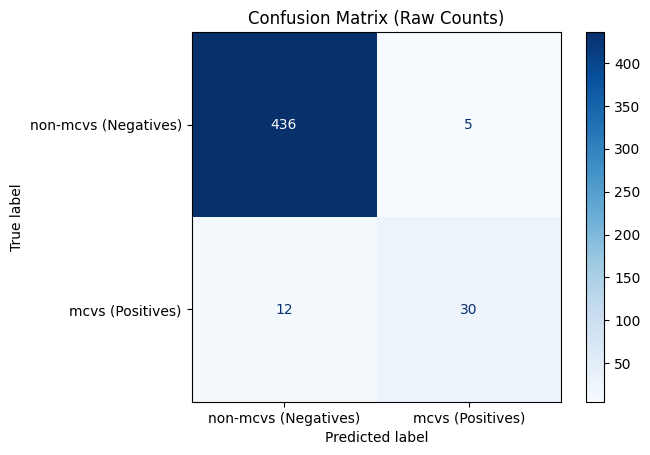

In [20]:
# For best model CONFUSION MATRIX + TP / TN / FP / FN IDENTIFICATION
# Class labels for clarity
class_names = ["non-mcvs (Negatives)", "mcvs (Positives)"]

# Plot confusion matrix (raw counts)
disp = ConfusionMatrixDisplay.from_estimator(
   best_model,
    X_test,
    y_test,
    display_labels=class_names,
    cmap=plt.cm.Blues #heatmap
)

disp.ax_.set_title("Confusion Matrix (Raw Counts)")
print("Confusion matrix (raw counts):")
print(disp.confusion_matrix)

plt.show()


# Extract TN, FP, FN, TP explicitly
# Label convention used in  code:
#   0 :ZTF names (negative, non-CV)
#   +1 :non-ZTF names (positive, CV)

cm = confusion_matrix(y_test, best_model.predict(X_test), labels=[0, 1])

TN, FP, FN, TP = cm.ravel()

In [21]:
#saving the best model
joblib.dump(best_model, "cv_classifier_best_model.pkl")

['cv_classifier_best_model.pkl']

In [22]:
#from this cell our prev work
# last used hyperparameters
train_size = 0.70
n_estimators = 130
#oter parameters were not varied
# Final train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.70,
    shuffle=True,
    #random_state=42
)

# Train final model
final_model =  XGBClassifier(
    n_estimators=130,
    n_jobs=-1,
    learning_rate=0.1, #Learning rate shrinks the contribution of each tree,Values must be in the range [0.0, inf),values by default float, default=0.1
    max_depth=3, #max_depthint or None, default=3
    eval_metric='logloss' 
)

final_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=130, n_jobs=-1,
              num_parallel_tree=None, ...)

In [23]:
#training set
final_model.fit(X_train, y_train)

print("Model trained successfully")


Model trained successfully


In [24]:
#predict model
y_pred = final_model.predict(X_test)
print(y_pred)


[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0
 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0
 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0]


In [25]:
#accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.9710144927536232


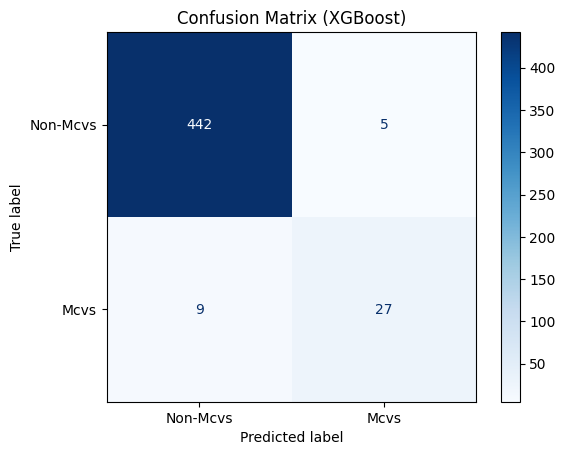

In [26]:
# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

class_names = ["Non-Mcvs", "Mcvs"]

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (XGBoost)")
# Save the figure to your current directory
plt.savefig('confusion matrix_plot.png', dpi=300, bbox_inches='tight')
plt.show()

In [27]:
#extract TP, TN, FP, FN
TN, FP, FN, TP = cm.ravel()
print("TN:", TN, "FP:", FP, "FN:", FN, "TP:", TP)

TN: 442 FP: 5 FN: 9 TP: 27


In [28]:
#saving the final model
joblib.dump(final_model, "cv_classifier_xgb_boost_biggie_set.pkl")

['cv_classifier_xgb_boost_biggie_set.pkl']